# NBM forecast guidance

The National Blend of Models is NOAA's forecast guidance built from many
models at once: it blends their output and corrects each for its known
biases, so it is what a forecaster starts from rather than one model's run.
NOAA issues it every hour to the anonymous `noaa-nbm-grib2-pds` bucket on
AWS, and one GRIB2 file holds one run at one forecast hour for one region: the
CONUS file is a 2.5 km grid of about 300 messages, 171 MB, with an index
sidecar listing each message's byte offset.

This walkthrough fetches the 2 m temperature from the first four hours of the
20 UTC run on 6 May 2024 as byte ranges, maps the first hour across the
country, and follows Oklahoma City into the evening. It needs `usdata[grib]`
and matplotlib; the download is about 6 MB and the run takes about ten
seconds.

In [1]:
from datetime import UTC, datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; xarray {xr.__version__}; numpy {np.__version__}")

Executed (UTC): 2026-09-24T06:14:35+00:00
usdata 0.26.0; xarray 2026.7.0; numpy 2.5.2


## Select

The manifest names one run, four hours, and one field. The window selects
runs by initialization time, so 20:00 to 20:00 UTC with `cycle: 20` is the run
started at 20 UTC on 6 May 2024. The blend has no hour 0: `forecast_hour: [1,
2, 3, 4]` is guidance valid at 21, 22, and 23 UTC and midnight. Later hours
thin out to every 3 and then every 6 hours on a schedule that varies by cycle,
and an hour a run does not publish is named after the listing.

`messages` names the field the way each file's `.idx` sidecar names it.
NBM index lines carry a further text for ensemble statistics, so
`TMP:2 m above ground` is the temperature itself and
`TMP:2 m above ground:1 hour fcst:ens std dev` would be its spread. The source
is named `forecast` so its files can be looked up by name.

In [2]:
print(manifest.read_text())

name: oklahoma-nbm-temperature
sources:
  - name: forecast
    dataset: noaa:nbm
    start: 2024-05-06T20:00:00Z
    end: 2024-05-06T20:00:00Z
    params:
      cycle: 20
      forecast_hour: [1, 2, 3, 4]
      messages: "TMP:2 m above ground"



## What arrives

One small GRIB2 file per hour: the one named message, fetched as a byte range
of that hour's CONUS object. The first pull writes `dataset.lock.json` beside
the manifest, pinning each range and each object's ETag; a restore re-issues
exactly those ranges, and a republished object is reported as drift.
`by_source` returns the files in valid-time order.

In [3]:
result = pull(manifest)
files = result.by_source["forecast"]
pd.DataFrame(
    {
        "valid (UTC)": item.asset.time.start.strftime("%Y-%m-%d %H:%M"),
        "bytes": item.provenance.size,
        "object MB": round(item.provenance.object_size / 1e6, 1),
        "message": item.provenance.source_url.rsplit("=", 1)[1],
        "checksum": item.provenance.checksum[:19] + "...",
    }
    for item in files
)

,valid (UTC),bytes,object MB,message,checksum
0,2024-05-06 21:00,1497346,171.1,279,sha256:505ca46ce4bd...
1,2024-05-06 22:00,1482290,167.9,273,sha256:afb8aab142b0...
2,2024-05-06 23:00,1466612,167.1,273,sha256:c19e57314393...
3,2024-05-07 00:00,1447461,173.3,281,sha256:a6724b446a6c...


In [4]:
first = files[0]
print("First file:", first.path.name)
print("Source:", first.provenance.source_url)
print("Retrieved (UTC):", first.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Selector:", first.provenance.selectors[0])
print(f"Total: {sum(item.provenance.size for item in files) / 1e6:.1f} MB", end=" ")
print(f"of {sum(item.provenance.object_size for item in files) / 1e6:.0f} MB in the four objects")

First file: blend.20240506.t20z.core.f001.co.part-efd96aedf377.grib2
Source: s3://noaa-nbm-grib2-pds/blend.20240506/20/core/blend.t20z.core.f001.co.grib2#messages=279
Retrieved (UTC): 2026-09-24T06:14:36+00:00
Selector: TMP:2 m above ground
Total: 5.9 MB of 679 MB in the four objects


The temperature is message 279 in the first hour's file and 273 in the next
two, so the position of a field is not fixed from hour to hour; naming it is
what keeps the selection right.

## Open

Each file is already a selection and opens without `select`. The variable is
`2t`, the ecCodes short name, in kelvin. The grid is Lambert conformal,
2345 × 1597 points about 2.5 km apart, so `latitude` and `longitude` are
two-dimensional, and longitudes use the 0 to 360 convention. The run and
valid times are in the variable's attributes.

In [5]:
fields = first.open()
temperature = fields["2t"]
print("Grid:", dict(fields.sizes), f"{fields.attrs['DxInMetres'] / 1000:.2f} km spacing")
print("Units:", temperature.attrs["units"], "·", temperature.attrs["name"])
print("Run:", temperature.attrs["reference_time"], "· valid:", temperature.attrs["valid_time"])

Grid: {'y': 1597, 'x': 2345} 2.54 km spacing
Units: K · 2 metre temperature
Run: 2024-05-06T20:00:00+00:00 · valid: 2024-05-06T21:00:00+00:00


A value at a place is the nearest grid point in two dimensions, after moving
longitudes to −180 to 180. Every hour shares the grid, so the point is found
once and read from each file in turn.

In [6]:
latitude = fields.latitude.values
longitude = np.where(
    fields.longitude.values > 180, fields.longitude.values - 360, fields.longitude.values
)
phi1, phi2 = np.radians(35.47), np.radians(latitude)  # Oklahoma City
dlat, dlon = phi2 - phi1, np.radians(longitude + 97.52)
h = np.sin(dlat / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlon / 2) ** 2
distance_km = 2 * 6371.0 * np.arcsin(np.sqrt(h))
y, x = np.unravel_index(distance_km.argmin(), distance_km.shape)
print(f"Nearest grid point: {latitude[y, x]:.3f} N {longitude[y, x]:.3f} E")
print(f"Distance from the city centre: {distance_km[y, x]:.1f} km")

central = timedelta(hours=-5)  # CDT
city = pd.DataFrame(
    {
        "valid (UTC)": item.asset.time.start.strftime("%H:%M"),
        "local (CDT)": (item.asset.time.start + central).strftime("%H:%M"),
        "forecast (°C)": round(float(item.open()["2t"][y, x]) - 273.15, 1),
    }
    for item in files
)
city

Nearest grid point: 35.475 N -97.509 E
Distance from the city centre: 1.2 km


,valid (UTC),local (CDT),forecast (°C)
0,21:00,16:00,26.2
1,22:00,17:00,26.3
2,23:00,18:00,26.1
3,00:00,19:00,25.8


## A first look

The first hour's guidance, valid at 21 UTC (4 pm in Oklahoma), over the whole
CONUS grid. The map plots the grid itself, which is already a Lambert
conformal projection, so distances are in kilometres along the grid.

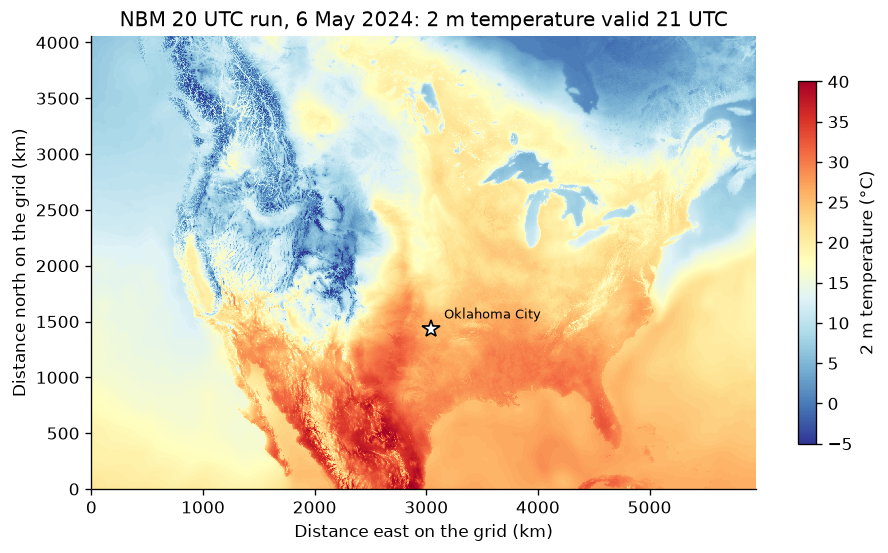

In [7]:
rows, cols = temperature.shape
spacing_km = fields.attrs["DxInMetres"] / 1000

fig, ax = plt.subplots(layout="constrained")
shaded = ax.imshow(
    temperature.values - 273.15,
    extent=(0, cols * spacing_km, 0, rows * spacing_km),
    cmap="RdYlBu_r",
    vmin=-5,
    vmax=40,
    interpolation="nearest",
)
ax.plot(
    x * spacing_km,
    (rows - 1 - y) * spacing_km,
    marker="*",
    markersize=11,
    color="white",
    markeredgecolor="black",
)
ax.annotate(
    "Oklahoma City",
    (x * spacing_km, (rows - 1 - y) * spacing_km),
    xytext=(8, 6),
    textcoords="offset points",
    fontsize=8,
)
ax.set_aspect("equal")
ax.grid(False)
ax.set(
    title="NBM 20 UTC run, 6 May 2024: 2 m temperature valid 21 UTC",
    xlabel="Distance east on the grid (km)",
    ylabel="Distance north on the grid (km)",
)
fig.colorbar(shaded, ax=ax, label="2 m temperature (°C)", shrink=0.8)
plt.show()

In [8]:
celsius = temperature.values - 273.15
hottest = np.unravel_index(int(np.nanargmax(celsius)), celsius.shape)
coldest = np.unravel_index(int(np.nanargmin(celsius)), celsius.shape)
for label, (i, j) in (("Warmest", hottest), ("Coldest", coldest)):
    print(f"{label}: {celsius[i, j]:.1f} °C at {latitude[i, j]:.2f} N {longitude[i, j]:.2f} E")
drop = city["forecast (°C)"].iloc[0] - city["forecast (°C)"].iloc[-1]
print(f"Oklahoma City cools {drop:.1f} °C from 21 UTC to midnight UTC")

Warmest: 41.1 °C at 27.10 N -101.57 E
Coldest: -14.1 °C at 51.37 N -125.26 E
Oklahoma City cools 0.4 °C from 21 UTC to midnight UTC


Cool air covered the Rockies and the northern High Plains while the southern
Plains and the East sat in warm air, hottest in northern Mexico south of the
Rio Grande. The coldest cell is a summit in the Coast Mountains of British
Columbia, and the terrain of the West shows cell by cell at 2.5 km. Oklahoma
City sat in the warm air and was expected to hold near 26 °C from 4 pm to
7 pm local time. The blend is guidance, not an observation: each value is the
expected temperature at one 2.5 km cell.

## Pin and cite

`verify` checks the cached bytes against the lockfile. Keep the manifest,
lockfile, and cached bytes together; `pull --update` accepts new ranges after
a republished object is reported as drift.

In [9]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:nbm
  NOAA National Blend of Models (NBM) was accessed on 2026-09-24 from https://registry.opendata.aws/noaa-nbm
  homepage: https://registry.opendata.aws/noaa-nbm/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-24; 4 checksummed assets (5,893,709 bytes) pinned by usdata 0.26.0
  sources: forecast


## What was awkward

- The CONUS grid stores every second row east to west
  (`alternativeRowScanning`), and the reader used to return those rows
  mirrored: the first map drawn for this notebook was a striped mirror image,
  and every value read at a point on half the rows came from the wrong
  column. The reader now reverses them; nothing in the file listing or the
  Dataset showed the problem short of drawing the field.
- The 171 MB CONUS file makes `messages` the only sensible way in, but the
  index vocabulary has to be discovered from the sidecar itself: NBM lines
  carry a fourth field for ensemble spread and probability thresholds, and
  nothing in `usdata info` says which selectors a dataset's files hold. The
  guide's table is the substitute for a listing of the index.
- Finding the grid point nearest a place takes a few lines of NumPy in every
  model walkthrough, after undoing the 0 to 360 longitude convention.
- Temperature arrives in kelvin with the ecCodes short name `2t`, which is
  not a valid Python identifier, so it is always read as `fields["2t"]`.
- The `grib` extra installs with pip alone on Linux, and on Windows through
  Python 3.13; macOS needs the ecCodes library from conda-forge or Homebrew
  first. The [reader reference](https://docs.usdata.dev/reference/readers/)
  has the details.